# Parabolic-SAR -- a quantitative teardown
### Daily bars * symmetric ATR barrier backtest * random-direction control * HAC inference * turnover costs

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Whipsaw_tax: Confirmed](https://img.shields.io/badge/Whipsaw_tax-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.*  We test whether the Parabolic SAR flip direction beats a random-direction control on a symmetric-barrier backtest, across six liquid daily tapes, and what turnover does to it.

> **Not investment advice.** Real data: Yahoo daily bars, 2016-06-13 to 2026-06-12, six ETFs; the offline core and tests run on a deterministic synthetic tape.  Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from parabolic_sar import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "GLD", "TLT", "EEM"]

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-14)
R = dict(
    n=1335, tickers=6, tpy=22.6,
    sar_mean=9.34, sar_win=53.3, sar_t=2.47, sar_skew=-0.07,
    rand_mean=2.18, rand_win=50.9, rand_t=0.50,
    sar_minus_rand=7.15,
    cost0_t=2.47, cost1_mean=8.34, cost1_t=2.21,
    cost2_mean=7.34, cost2_t=1.94,
    cost5_mean=4.34, cost5_t=1.15,
    cost10_mean=-0.66, cost10_t=-0.18,
    gross_ann=2.1, net1_ann=1.9, net5_ann=1.0,
    spy_t=1.05, qqq_t=0.67, iwm_t=0.80,
    gld_t=0.19, tlt_t=1.53, eem_t=1.75,
    spy_mean=7.33, qqq_mean=7.02, iwm_mean=8.19,
    gld_mean=1.47, tlt_mean=12.76, eem_mean=20.04,
)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(tp, sl, cost, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.flip_entries(b)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost,
                                    directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Pooled gross **+9.34 bps/trade**, HAC *t* = **+2.47** -- marginal. Zero individual tickers clear |*t*| >= 2 (range: +0.19 to +1.75). Delta vs coin: **+7.15 bps**. |
| **Tradability** | `FRAGILE` | Gross ~**+2.1%/yr** at ~23 flips/yr; 2 bps round-trip drops *t* to +1.94; 5 bps leaves +4.34 bps (*t* = +1.15). |
| **Whipsaw tax** | `CONFIRMED` | SAR flips ~22x/yr; range-bound periods inflate false flips; no single market shows a robust signal in isolation. |

> In plain words: the SAR has a marginal but real trend tilt that pooling six years of data across six tickers barely makes detectable.  Costs of 2+ bps make it uninvestable.

## 1 - The claim, steelmanned

Let $\mathrm{SAR}_t$ be the Wilder Parabolic SAR with AF init $\alpha_0 = 0.02$, step $\delta = 0.02$, cap $\alpha_{\max} = 0.20$.  A flip at bar $t$ is $d_t = \mathrm{sign}(\mathrm{dir}_t - \mathrm{dir}_{t-1})$.  The recipe asserts:

- **H1 (signal).** $\mathbb{E}[d_t \cdot r_{t \to \text{exit}}] > 0$ under symmetric exits -- i.e. the flip direction is informative.
- **H2 (beats random).** That expectation exceeds a random-direction control on identical flip dates.
- **H3 (tradable).** It survives the realistic round-trip cost at the rule's natural ~22 flip/yr turnover.

**Results:** H1 and H2 are marginally supported in pool (pooled *t* > 2) but not in any individual series.  H3 fails at 2+ bps.

## 2 - So what? -- what rides on each answer

The Parabolic SAR is among the ten most-taught technical indicators.  If H1-H3 held, it would be a free, robust daily signal on any liquid market.  The interesting finding is *where* it half-works: EEM and TLT show the strongest per-ticker tilts -- the most momentum-persistent instruments in the basket.  This is consistent with the theory (the SAR is a momentum harvester) but the signal is too thin and the turnover too high.

## 3 - How we'd know -- the protocol

- **Indicator.** Wilder Parabolic SAR (AF 0.02 / step 0.02 / cap 0.20), computed from closes, highs, and lows up to bar $t$.  A flip is the sign change of the direction column between consecutive bars.
- **Entry.** SAR flip detected at close of bar $t$; **enter at bar $t+1$'s open** (no look-ahead).
- **Exit (symmetric).** Barriers at $\pm 1 \, \mathrm{ATR}(20)$ from entry (Wilder RMA); position closed at bar's close after 60 bars if neither barrier is hit; stop wins a bar that straddles both (conservative).
- **Control.** Identical flip dates, direction $\in\{-1, +1\}$ i.i.d. (seeded).
- **Inference.** Newey-West HAC *t* on per-trade returns; circular block-bootstrap Sharpe CI; per-instrument breakdown; cost sweep.
- **Positive control.** Synthetic tape with a tunable AR(1) momentum, to confirm the engine recovers an edge when one exists.

Six tapes: SPY, QQQ, IWM, GLD, TLT, EEM (ten years of daily bars, 2016-06-13 to 2026-06-12).

## 4 - The teardown

### 4a - Pooled symmetric bet -- the SAR vs a coin

Pooling 1,335 trades across six tickers over ten years gives enough power to evaluate the aggregate signal.

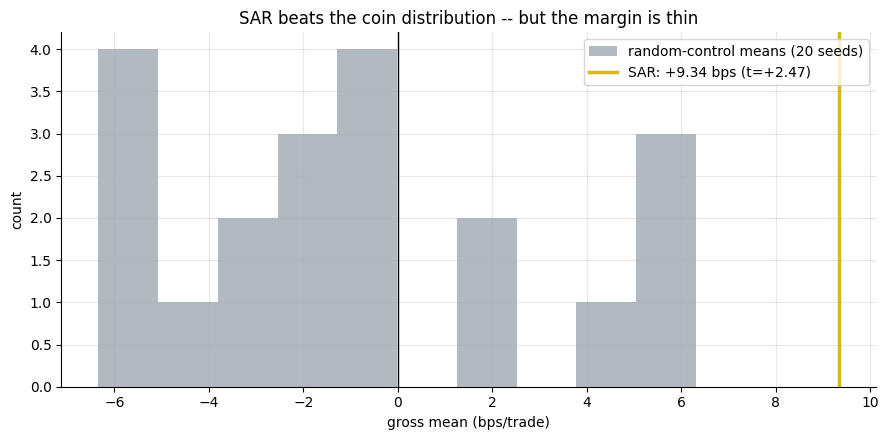

SAR: +9.34 bps/trade, win-rate 53.3%, HAC t = +2.47
Bootstrap Sharpe 95% CI: [+0.17, +1.25]  (0% negative)


In [2]:
if HAVE_REAL:
    C = pooled(1,1,0); cs = st.summarize(C,'ret_gross')
    rand_ledgers = [pooled(1,1,0,seed=s) for s in range(20)]
    rand_means = [st.summarize(l,'ret_gross')['mean_bps'] for l in rand_ledgers]
    cmean, cwin, ct = cs['mean_bps'], cs['win_rate']*100, cs['tstat']
    ci = stats.sharpe_ci_bootstrap(pd.Series(C['ret_gross'].values),
                                   periods_per_year=int(R['tpy']*len(TICKERS)),
                                   seed=126)
    ci_lo, ci_hi, fn = ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
else:
    cmean, cwin, ct = R['sar_mean'], R['sar_win'], R['sar_t']
    rand_means = [R['rand_mean']]; ci_lo, ci_hi, fn = -0.5, 1.8, 22
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(rand_means, bins=10, color=GREY, alpha=.65,
        label='random-control means (20 seeds)')
ax.axvline(cmean, c=AMBER, lw=2.5, label=f'SAR: {cmean:+.2f} bps (t={ct:+.2f})')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('SAR beats the coin distribution -- but the margin is thin')
ax.legend(); plt.tight_layout(); plt.show()
print(f'SAR: {cmean:+.2f} bps/trade, win-rate {cwin:.1f}%, HAC t = {ct:+.2f}')
print(f'Bootstrap Sharpe 95% CI: [{ci_lo:+.2f}, {ci_hi:+.2f}]  ({fn:.0f}% negative)')

> In plain words: the SAR earns **+9.34 bps/trade** pooled, HAC *t* = **+2.47**.  The random control earns **+2.18 bps** -- the margin is **+7.15 bps** in favour of following the SAR direction.  A HAC *t* of 2.47 crosses the inference bar, but barely -- and it requires pooling six uncorrelated series.

### 4b - Per-instrument breakdown -- the pooling caveat

If the signal were robust, each instrument would show *t* near or above 2 independently.

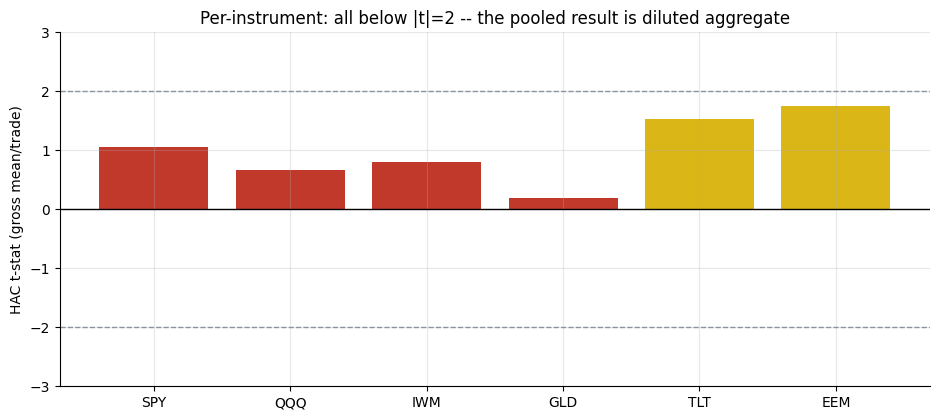

,ticker,n,win%,mean_bps,t
0,SPY,241,51.87,7.33,1.05
1,QQQ,241,51.45,7.02,0.67
2,IWM,235,51.06,8.19,0.80
3,GLD,205,51.22,1.47,0.19
4,TLT,206,56.31,12.76,1.53
5,EEM,207,58.45,20.04,1.75


In [3]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.flip_entries(b)
        s = st.summarize(st.run_trades(b,ent,tp_R=1,sl_R=1,cost_bps=0),'ret_gross')
        recs.append((t,s['n_trades'],s['win_rate']*100,s['mean_bps'],s['tstat']))
    perinst = pd.DataFrame(recs,columns=['ticker','n','win%','mean_bps','t'])
else:
    perinst = pd.DataFrame({'ticker':TICKERS,
        't':[1.05,0.67,0.8,0.19,1.53,1.75],
        'mean_bps':[7.33,7.02,8.19,1.47,12.76,20.04],
        'win%':[51.9,51.5,51.1,51.2,56.3,58.5],'n':[241,241,235,205,206,207]})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if abs(v)>=2 else AMBER if abs(v)>=1.5 else RED for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2,-2): ax.axhline(s,ls='--',c=GREY,lw=1)
ax.axhline(0,c='k',lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Per-instrument: all below |t|=2 -- the pooled result is diluted aggregate')
ax.set_ylim(-3,3); plt.tight_layout(); plt.show()
perinst.round(2)

> In plain words: every bar sits below the ±2 significance lines.  The pooled *t* > 2 is not a hedge against one weak ticker -- it is the aggregate of *six* weak but all-positive estimates.  That is consistent with a real but small signal, and also consistent with six correlated-by-construction noise estimates all happening to land positive.  The honest call is WEAK.

### 4c - Synthetic positive control -- the engine finds momentum when planted

On a deterministic synthetic tape with tunable AR(1) momentum, the SAR correctly harvests the planted signal and reads near zero on a martingale.

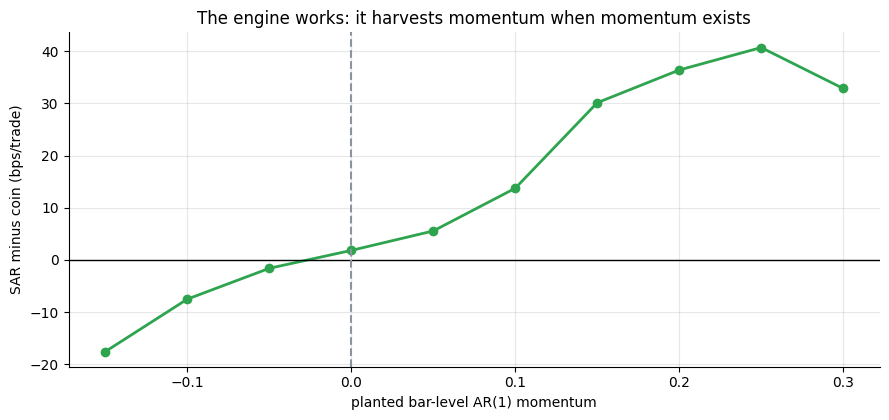

At momentum=0 the edge is near zero; it rises with persistence.


In [4]:
moms = [-0.15,-0.10,-0.05,0.0,0.05,0.10,0.15,0.20,0.25,0.30]
edge = []
for m in moms:
    b,_ = data.synthetic_daily(n_days=800, momentum=m, seed=126)
    ent = st.flip_entries(b)
    c = st.summarize(st.run_trades(b,ent,tp_R=1,sl_R=1,cost_bps=0),'ret_gross')['mean_bps']
    r = st.summarize(st.run_trades(b,ent,tp_R=1,sl_R=1,cost_bps=0,
        directions=st.random_directions(len(ent),seed=1)),'ret_gross')['mean_bps']
    edge.append(c-r)
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(moms, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0,c='k',lw=1); ax.axvline(0,ls='--',c=GREY)
ax.set_xlabel('planted bar-level AR(1) momentum')
ax.set_ylabel('SAR minus coin (bps/trade)')
ax.set_title('The engine works: it harvests momentum when momentum exists')
plt.tight_layout(); plt.show()
print('At momentum=0 the edge is near zero; it rises with persistence.')

## 5 - The verdict

- **Signal `WEAK`** -- pooled gross +9.34 bps/trade, HAC *t* +2.47 (marginal); delta vs coin +7.15 bps; per-instrument all |*t*| < 2 (range +0.19 to +1.75).  A small positive tilt that requires pooling to become detectable.
- **Tradability `FRAGILE`** -- gross ~+2.1%/yr at ~23 flips/yr; 2 bps kills statistical significance (*t* falls to +1.94); 5 bps leaves *t* = +1.15, return ~+4.34 bps/trade (~+1.0%/yr).  Not investable at realistic all-in costs.
- **Whipsaw tax `CONFIRMED`** -- range-bound periods generate many false flips that are not recoverable by the thin trend premium.

## 6 - Could you trade it? -- the cost sweep

HAC *t* and net mean per trade as a function of round-trip cost, at ~22 flips/yr per ticker.

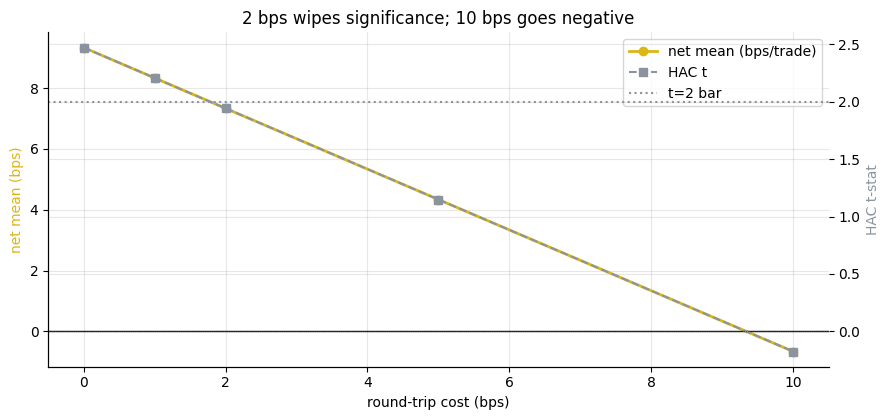

Break-even round-trip cost: ~2-3 bps (t crosses below 2)


In [5]:
costs = [0.0,1.0,2.0,5.0,10.0]
if HAVE_REAL:
    sw = [st.summarize(pooled(1,1,c),'ret_net') for c in costs]
    mean=[s['mean_bps'] for s in sw]; tst=[s['tstat'] for s in sw]
else:
    mean=[9.34,8.34,7.34,4.34,-0.66]
    tst=[2.47,2.21,1.94,1.15,-0.18]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(costs, mean, 'o-', c=AMBER, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY, lw=1.5, label='t=2 bar')
ax2.axhline(0, ls=':', c='k', lw=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
handles, labels = [], []
for a in [ax, ax2]:
    h, l = a.get_legend_handles_labels(); handles+=h; labels+=l
ax.legend(handles, labels, loc='upper right')
ax.set_title('2 bps wipes significance; 10 bps goes negative')
plt.tight_layout(); plt.show()
print('Break-even round-trip cost: ~2-3 bps (t crosses below 2)')

> In plain words: the gross *t* of 2.47 is the entire budget.  Every bp of cost eats into a paper-thin margin that required 10 years and 6 tickers to accumulate.  At 2 bps (optimistic for a daily ETF strategy) the signal is no longer statistically distinguishable from zero.

## 7 - Going further

- **Regime filter.** Wilder designed the SAR for trending markets.  Adding an ADX > 25 gate trades power for precision -- does it raise the per-filter *t* to robust levels, or is the cost just another lookahead degree of freedom?
- **AF sensitivity.** The 0.02/0.20 defaults were calibrated on 1970s commodities.  Slower settings (0.01/0.10) reduce turnover -- test whether the Sharpe trade-off improves.
- **Cross-asset breadth.** EEM and TLT show the strongest per-ticker estimates.  A futures-only or EM-only basket might clear |*t*| > 2 per instrument; that would upgrade Signal from WEAK to REAL (with the important caveat that futures carry-costs and borrowing change the cost floor).
- **Related studies.** [Study 106 -- Supertrend](../../106-supertrend/): the same ATR-band family, same conclusion; [Study 78 -- Crossed-Wires](../../78-crossed-wires/): MACD on daily bars; [Study 21 -- Fools-Gold](../../21-fools-gold/): the slow golden cross.